In [1]:
import numpy as np
import pandas as pd
import cv2
import PIL
import pytesseract

In [8]:
img_cv = cv2.imread('./Selected/084.jpeg')

cv2.waitKey(0)
cv2.destroyAllWindows()

In [3]:
type(img_cv)

numpy.ndarray

In [9]:
img_pl = PIL.Image.open('./Selected/084.jpeg')

In [10]:
type(img_pl)

PIL.JpegImagePlugin.JpegImageFile

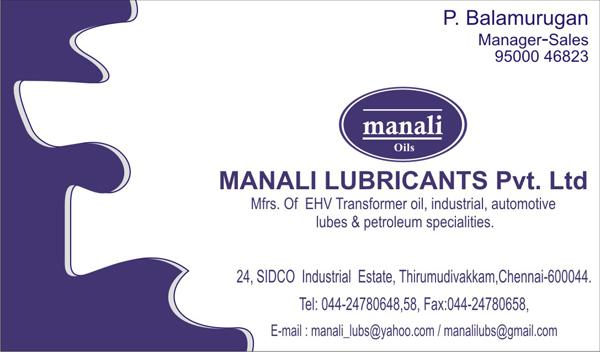

In [11]:
img_pl

### Text from Image

In [12]:
text_cv = pytesseract.image_to_string(img_cv)

In [13]:
import pytesseract

In [14]:
text_cv = pytesseract.image_to_string(img_cv)

In [15]:
print(text_cv)

P. Balamurugan
Manager-Sales
95000 46823,

   
  
 

MANALI LUBRICANTS Pvt. Ltd

Mfrs. Of EHV Transformer oil, industrial, automotive
lubes & petroleum specialties.

24, SIDCO Industrial Estate, Thirumudivakkam,Chennai-600044.
Tel: 044-24780648,58, Fax:044-24780658,
E-mail: manal_lubs@yahoo.com / manaliubs@gmail com



In [16]:
text_p1 = pytesseract.image_to_string(img_pl)

In [17]:
print(text_p1)

P. Balamurugan
Manager-Sales
95000 46823,

   
  
 

MANALI LUBRICANTS Pvt. Ltd

Mfrs. Of EHV Transformer oil, industrial, automotive
lubes & petroleum specialties.

24, SIDCO Industrial Estate, Thirumudivakkam, Chennai-600044.
Tel; 044-24780648,58, Fax:044-24780658,
E-mail: manal_lubs@yahoo.com / manaliubs@gmail com



### Image To Data

In [19]:
data = pytesseract.image_to_data(img_cv)

In [20]:
#data.split('\n')
dataList = list(map(lambda x: x.split('\t'),data.split('\n')))
df = pd.DataFrame(dataList[1:],columns=dataList[0])

In [21]:
df.head(10)

,level,page_num,block_num,par_num,line_num,word_num,left,top,width,height,conf,text
0,1,1,0,0,0,0,0,0,600,352,-1,
1,2,1,1,0,0,0,444,10,144,52,-1,
2,3,1,1,1,0,0,444,10,144,52,-1,
3,4,1,1,1,1,0,444,10,143,19,-1,
4,5,1,1,1,1,1,444,10,14,15,79,P.
5,5,1,1,1,1,2,467,10,120,19,92,Balamurugan
6,4,1,1,1,2,0,479,33,109,16,-1,
7,5,1,1,1,2,1,479,33,109,16,88,Manager-Sales
8,4,1,1,1,3,0,495,50,93,12,-1,
9,5,1,1,1,3,1,495,50,44,12,68,95000


In [22]:
df.dropna(inplace=True) #drop the missing values in rows
col_int = ['level','page_num','block_num','par_num','line_num','word_num','left','top','width','height','conf']
df[col_int] = df[col_int].astype(int)

In [23]:
df.dtypes

level         int64
page_num      int64
block_num     int64
par_num       int64
line_num      int64
word_num      int64
left          int64
top           int64
width         int64
height        int64
conf          int64
text         object
dtype: object

In [ ]:
image = img_cv.copy()
level = 'word'
for l,x,y,w,h,c,txt in df [['level','left','top','width','height','conf','text']].values:
    #print(l,x,y,w,h,c)
    if level == 'page':
        if l == 1:
            cv2.rectangle(image,(x,y),(x+w,y+h),(0,0,0),2)
        else:
            continue

    elif level == 'block':
        if l == 2:
            cv2.rectangle(image,(x,y),(x+w,y+h),(255,0,0),2)
        else:
            continue

    elif level == 'para':
        if l == 3:
            cv2.rectangle(image,(x,y),(x+w,y+h),(0,255,0),2)
        else:
            continue
    elif level == 'line':
        if l == 4:
            cv2.rectangle(image,(x,y),(x+w,y+h),(0,0,255),2)
        else:
            continue
    elif level == 'word':
        if l == 5:
            cv2.rectangle(image,(x,y),(x+w,y+h),(0,255,0),2)
            cv2.putText(image,txt,(x,y),cv2.FONT_HERSHEY_PLAIN,1,(255,0,0),2)
        else:
            continue

cv2.imshow("bounding box",image)
cv2.waitKey()
cv2.destroyAllWindows()   